In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 0) 参数集中区（你只改这里）
# =========================
CONFIG = {
    "raw_file_path": "accelero and gyro data.txt",
    "fs": 50,  # 采样率 Hz

    # —— 滤波器设计参数——
    # filter_type: "lowpass" | "highpass" | "bandpass" | "bandstop"
    "filter": {
        "design": "butter",       # "butter"（推荐先用）/ 你以后也可以扩展 cheby、ellip
        "filter_type": "bandpass",
        "order": 4,               # Butterworth 阶数（注意：bandpass 下阶数解释见下）
        "lowcut_hz": 0.02,         # 带通下截止（Hz）
        "highcut_hz": 0.2,       # 带通上截止（Hz）  
        "steady_init_iter": 5000  # 复现 C++ initFilterSteadyState 的迭代次数
    },

    # 绘图参数（可选）
    "plot": {
        "alpha_raw": 0.35,
        "lw_filt": 2.0
    }
}


CONFIG2 = {
    "raw_file_path": "accelero and gyro data.txt",
    "fs": 50,
    "filter": {
        "design": "butter",
        "filter_type": "lowpass",  # ✅ 必须确保这里是 lowpass
        "order": 4,
        "cutoff_hz": 0.2,
        "steady_init_iter": 5000          # ✅ 截止频率设低（如 0.2Hz 或 0.1Hz）用来抓取重力
    },
    # ... 其他保持不变
}
# =========================
# 1) 统一颜色规则（Accel & Gyro：x蓝 y绿 z红）
# =========================
axis_colors = {'x': 'blue', 'y': 'green', 'z': 'red'}

ACC_COLORS = {'Accel_x': axis_colors['x'], 'Accel_y': axis_colors['y'], 'Accel_z': axis_colors['z']}
GYRO_COLORS = {'gyro_x': axis_colors['x'],  'gyro_y': axis_colors['y'],  'gyro_z': axis_colors['z']}

RAW_IMU_COLS = ['Accel_x','Accel_y','Accel_z','gyro_x','gyro_y','gyro_z']

print("✅ 配置完成")
print("文件:", CONFIG["raw_file_path"])
print("fs:", CONFIG["fs"], "Hz")
print("滤波:", CONFIG["filter"])


✅ 配置完成
文件: accelero and gyro data.txt
fs: 50 Hz
滤波: {'design': 'butter', 'filter_type': 'bandpass', 'order': 4, 'lowcut_hz': 0.02, 'highcut_hz': 0.2, 'steady_init_iter': 5000}


In [3]:
from scipy import signal

def design_sos_from_config(cfg):
    fs = cfg["fs"]
    fcfg = cfg["filter"]
    ftype = fcfg["filter_type"].lower()
    order = int(fcfg["order"])

    nyq = fs / 2.0

    # 频率合法性检查（别让你踩坑）
    if ftype in ("bandpass", "bandstop"):
        low = float(fcfg["lowcut_hz"])
        high = float(fcfg["highcut_hz"])
        if not (0 < low < high < nyq):
            raise ValueError(f"band* 截止频率必须满足 0 < lowcut < highcut < fs/2({nyq}). 当前: {low}, {high}")
        wn = [low, high]
    else:
        # lowpass / highpass
        cut = float(fcfg.get("cutoff_hz", fcfg.get("highcut_hz", 5.0)))
        if not (0 < cut < nyq):
            raise ValueError(f"{ftype} 截止频率必须满足 0 < cutoff < fs/2({nyq}). 当前: {cut}")
        wn = cut

    # Butterworth SOS
    if fcfg["design"].lower() == "butter":
        sos = signal.butter(order, wn, btype=ftype, fs=fs, output="sos")
    else:
        raise NotImplementedError("目前只实现 butter，你要 cheby/ellip 我再给你加。")

    return sos

SOS_AUTO = design_sos_from_config(CONFIG)
print("✅ SOS 生成完成，stage 数:", SOS_AUTO.shape[0])

✅ SOS 生成完成，stage 数: 4


In [4]:

df = pd.read_csv(
    CONFIG["raw_file_path"],
    sep="\t",          # ✅ 关键
    engine="python"    # ✅ 防止异常格式
)


df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.str.contains(r'^Unnamed', regex=True)]
df = df.replace(r'^\s*$', np.nan, regex=True)

df_imu = df[RAW_IMU_COLS].copy()
for c in RAW_IMU_COLS:
    df_imu[c] = pd.to_numeric(df_imu[c], errors='coerce')

df_imu = df_imu.dropna(subset=RAW_IMU_COLS).reset_index(drop=True)
df_imu["time_sec"] = np.arange(len(df_imu), dtype=np.int64) / CONFIG["fs"]

print("数据长度:", len(df_imu))
print("总时长(s):", df_imu["time_sec"].iloc[-1])


class SosState:
    def __init__(self):
        self.z1 = 0.0
        self.z2 = 0.0

class FilterChannel:
    def __init__(self, sos_coeffs):
        self.sos_coeffs = np.array(sos_coeffs, dtype=np.float64)
        self.num_stages = self.sos_coeffs.shape[0]
        self.states = [SosState() for _ in range(self.num_stages)]

    def reset(self):
        for s in self.states:
            s.z1 = 0.0
            s.z2 = 0.0

def sos_filter_single(sec, x, state):
    b0, b1, b2, a0, a1, a2 = sec
    out = b0 * x + state.z1
    state.z1 = b1 * x - a1 * out + state.z2
    state.z2 = b2 * x - a2 * out
    return out

def sos_filter_cascade(channel, x):
    y = x
    for k in range(channel.num_stages):
        y = sos_filter_single(channel.sos_coeffs[k], y, channel.states[k])
    return y

def init_filter_steady_state(channel, dc_offset, n_iter=5000):
    channel.reset()
    for _ in range(int(n_iter)):
        sos_filter_cascade(channel, dc_offset)

def apply_sos_to_h(df_in, sos_coeffs, steady_iter):
    out = df_in.copy()
    channels = {col: FilterChannel(sos_coeffs) for col in RAW_IMU_COLS}

    # 第一帧稳态初始化
    for col, ch in channels.items():
        init_filter_steady_state(ch, out[col].iloc[0], n_iter=steady_iter)

    # 逐点滤波，写回 *_h
    for col, ch in channels.items():
        out[col + "_h"] = [sos_filter_cascade(ch, x) for x in out[col].to_numpy(np.float64)]

    return out

df_proc = apply_sos_to_h(
    df_imu,
    sos_coeffs=SOS_AUTO,
    steady_iter=CONFIG["filter"]["steady_init_iter"]
)

print("✅ 已生成:", [c + "_h" for c in RAW_IMU_COLS])

数据长度: 6248
总时长(s): 124.94
✅ 已生成: ['Accel_x_h', 'Accel_y_h', 'Accel_z_h', 'gyro_x_h', 'gyro_y_h', 'gyro_z_h']


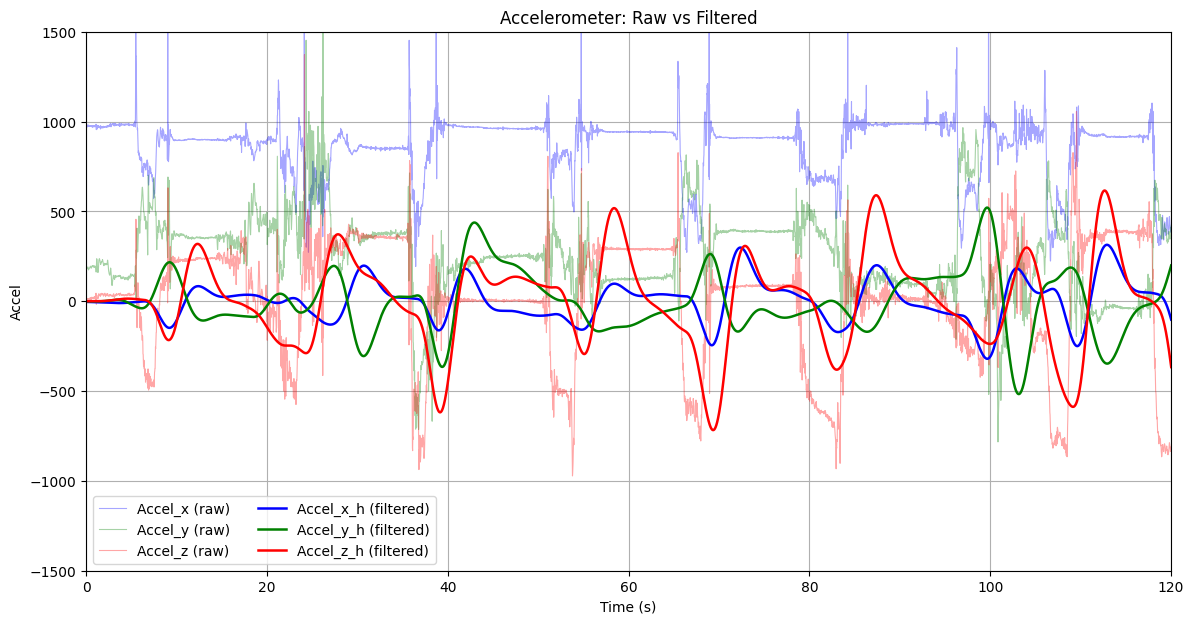

In [6]:
plt.figure(figsize=(14, 7))

# 选择滤波后列：优先 *_h_py，没有就用 *_h
acc_h_cols = ['Accel_x_h_py', 'Accel_y_h_py', 'Accel_z_h_py']
if not all(c in df_proc.columns for c in acc_h_cols):
    acc_h_cols = ['Accel_x_h', 'Accel_y_h', 'Accel_z_h']

# ---------- 原始（raw） ----------
plt.plot(df_proc['time_sec'], df_proc['Accel_x'],
         label='Accel_x (raw)', color=axis_colors['x'], linewidth=0.8, alpha=0.35)
plt.plot(df_proc['time_sec'], df_proc['Accel_y'],
         label='Accel_y (raw)', color=axis_colors['y'], linewidth=0.8, alpha=0.35)
plt.plot(df_proc['time_sec'], df_proc['Accel_z'],
         label='Accel_z (raw)', color=axis_colors['z'], linewidth=0.8, alpha=0.35)

# ---------- 滤波后（filtered） ----------
plt.plot(df_proc['time_sec'], df_proc[acc_h_cols[0]],
         label=f'{acc_h_cols[0]} (filtered)', color=axis_colors['x'], linewidth=1.8)
plt.plot(df_proc['time_sec'], df_proc[acc_h_cols[1]],
         label=f'{acc_h_cols[1]} (filtered)', color=axis_colors['y'], linewidth=1.8)
plt.plot(df_proc['time_sec'], df_proc[acc_h_cols[2]],
         label=f'{acc_h_cols[2]} (filtered)', color=axis_colors['z'], linewidth=1.8)

plt.xlabel("Time (s)")
plt.ylabel("Accel")
plt.title("Accelerometer: Raw vs Filtered")
plt.xlim(0, 120)
plt.ylim(-1500, 1500)
plt.legend(ncol=2)
plt.grid(True)
plt.show()


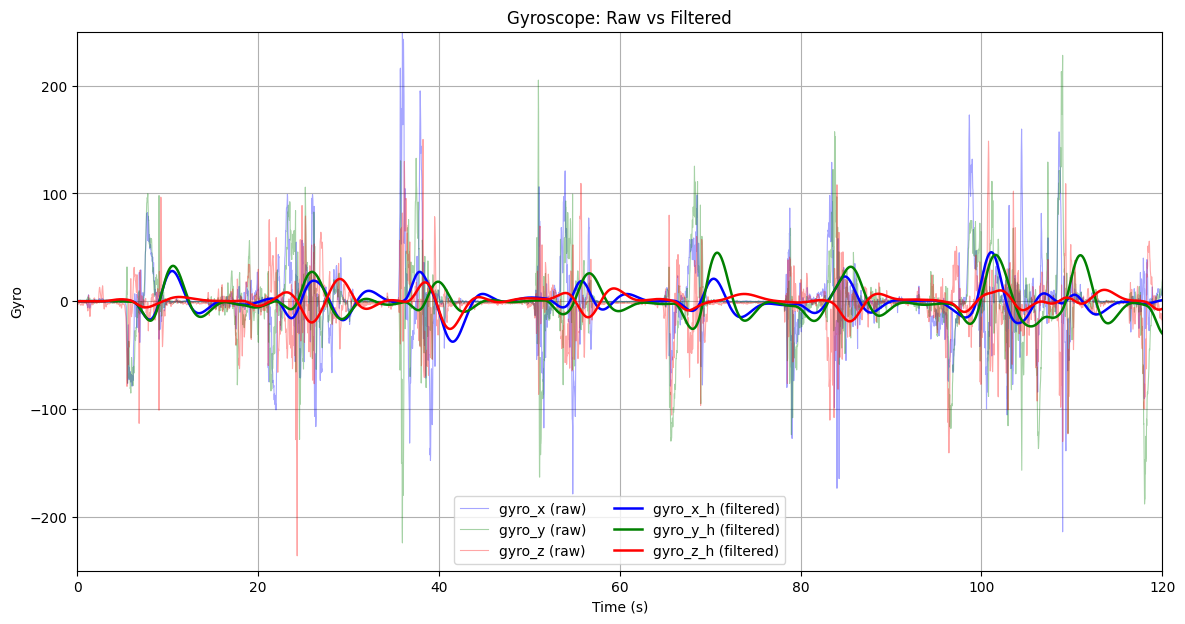

In [7]:
plt.figure(figsize=(14, 7))

# 选择滤波后列：优先 *_h_py，没有就用 *_h
gyro_h_cols = ['gyro_x_h_py', 'gyro_y_h_py', 'gyro_z_h_py']
if not all(c in df_proc.columns for c in gyro_h_cols):
    gyro_h_cols = ['gyro_x_h', 'gyro_y_h', 'gyro_z_h']

# ---------- 原始（raw） ----------
plt.plot(
    df_proc['time_sec'],
    df_proc['gyro_x'],
    label='gyro_x (raw)',
    color=axis_colors['x'],
    linewidth=0.8,
    alpha=0.35
)
plt.plot(
    df_proc['time_sec'],
    df_proc['gyro_y'],
    label='gyro_y (raw)',
    color=axis_colors['y'],
    linewidth=0.8,
    alpha=0.35
)
plt.plot(
    df_proc['time_sec'],
    df_proc['gyro_z'],
    label='gyro_z (raw)',
    color=axis_colors['z'],
    linewidth=0.8,
    alpha=0.35
)

# ---------- 滤波后（filtered） ----------
plt.plot(
    df_proc['time_sec'],
    df_proc[gyro_h_cols[0]],
    label=f'{gyro_h_cols[0]} (filtered)',
    color=axis_colors['x'],
    linewidth=1.8
)
plt.plot(
    df_proc['time_sec'],
    df_proc[gyro_h_cols[1]],
    label=f'{gyro_h_cols[1]} (filtered)',
    color=axis_colors['y'],
    linewidth=1.8
)
plt.plot(
    df_proc['time_sec'],
    df_proc[gyro_h_cols[2]],
    label=f'{gyro_h_cols[2]} (filtered)',
    color=axis_colors['z'],
    linewidth=1.8
)

plt.xlabel("Time (s)")
plt.ylabel("Gyro")
plt.title("Gyroscope: Raw vs Filtered")
plt.xlim(0, 120)

# ✅ 这里的 y 轴范围你可以按你数据量级改
plt.ylim(-250, 250)

plt.legend(ncol=2)
plt.grid(True)
plt.show()